# Spikes Sym(bolic)

In [2]:
from typing import Optional, Tuple, Union, Any, Dict
import sympy
import sympy as sp
from sympy import symbols, sympify, pprint
from sympy import Function, Eq, dsolve, Derivative, checkodesol,lambdify,re, im, Add
from sympy.matrices import Matrix, eye, zeros, ones, diag, GramSchmidt
from sympy.solvers import solve
from sympy.abc import x
import cmath
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [12]:
sp.init_printing(use_unicode=True)

In [328]:
from sympy import latex
from IPython.display import Math, Latex

def _slatex(arg):
    if isinstance(arg, str):
        return latex(sp.symbols(arg))
    else:
        return latex(arg)   

def _latex2(l, sep=' = ', sep_line='\ \ ;\ \ '):
    largs_ = []
    for arg in l:
        if isinstance(arg, tuple):
            largs_.append(f'{latex(arg[0])}{sep}{latex(arg[1])}')        
        else:
            largs_.append(_slatex(arg))        
    return sep_line.join(largs_)

def _latex(*args, sep_eq=' = ', sep_line='\ \ ;\ \ '):
    largs = []
    sep = sep_eq
    for arg in args:
        if isinstance(arg, dict):
            largs_ = []
            for key,value in arg.items():
                largs_.append(_latex(key, value)) 
            largs.append(sep_line.join(largs_))                            
            sep = sep_line
        elif isinstance(arg, list):
            largs.append(_latex(*arg))                                            
            sep = sep_line
        else:
            largs.append(_slatex(arg))   
    ms = sep_eq.join(largs)
    return ms

def eqdisplay(*args):
    ms = _latex(*args)
    display(Math(ms))

def ldisplay(*args):
    def _latex(args, sep=' = '):
        largs = []
        if isinstance(args, list):
            for arg in args:
                if isinstance(arg, str):
                    largs.append(latex(sp.symbols(arg)))   
                else:
                    largs.append(latex(arg))   
            ms = sep.join(largs)
            return ms
        else:
            return _slatex(arg)

    largs = []                
    for arg in args:
        largs.append(_latex(arg))
    ms = '\ \ ;\ \ '.join(largs)
    display(Math(ms))

def mdisplay(*args):
    for arg in args:
        if isinstance(arg, list):
            for value in arg:
                if isinstance(value, dict):
                    eqdisplay(value)
                else:
                    display(value)
        elif isinstance(arg, dict):
            for key, value in arg.items():
                if isinstance(value, dict):
                    display(Math(f'{_slatex(key)}\ \ : \ \ {_latex(value)}'))
                else:
                    eqdisplay(key, value)
        else:
           eqdisplay(arg) 
            

    
a,b,c = sp.symbols('a b c')
eqdisplay('x', a+b, b+c)
eqdisplay('x', *[a+b, b+c])
eqdisplay({'x': a+1, 'y': 2})
#eqdisplay({'u': a+1, 'y': 2}, {'w': a+1, 'w': 2})
eqdisplay(['k', a+b, b+c], ['v', c])
mdisplay({'r': a+b, 's': c})
mdisplay([{'x': a+b, 'y': c}, {'y': a}])
mdisplay({'A': {'x': a+b, 'y': c}, 'B': {'y': [a+2, c+1]}})



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
import numpy as np

def make_bin_states(N, width=None):
    """
    Return a 2D array where row i is the binary representation of integer i.

    Parameters
    ----------
    N : int
        Number of integers (0 to N-1).
    width : int, optional
        Number of bits. If None, uses minimum required bits.

    Returns
    -------
    ndarray of shape (N, width)
        Binary matrix.
    """
    if width is None:
        # smallest number of bits needed to represent N-1
        width = max(1, int(np.ceil(np.log2(N))))

    # numbers 0 .. N-1
    x = np.arange(N, dtype=np.uint32)

    # generate bit mask for each bit position
    bit_mask = 1 << np.arange(width-1, -1, -1)

    # matrix where each entry is (x & mask) > 0
    return ((x[:, None] & bit_mask) > 0).astype(int)

#states = make_bin_states(4)

def make_states(N):
    return make_bin_states(N)


In [259]:

def simplify_all(exprs):
    if isinstance(exprs, dict):
        return {key: value.simplify() for key, value in exprs.items() }
    elif isinstance(exprs, list):
        return [value.simplify() for value in exprs ]
    else:
        return exprs.simplify()
        
def doit_all(exprs):
    if isinstance(exprs, dict):
        return {key: value.doit() for key, value in exprs.items() }
    elif isinstance(exprs, list):
        return [value.doit() for value in exprs ]
    else:
        return exprs.doit()

class SVar():
    """
    """
    def __init__(self,
                 name: Optional[str] = None,
                 shape: Optional[Any] = None,
                 params: Optional[Any] = None,
                 auto_sample: bool = False,
                 monitor: Optional[Any] = None,
                 viewer: Optional[Any] = None,
                 callback: Optional[Any] = None):
        #super().__init__(name=name)
        self.name = name
        self.shape = shape
        self.N = self.shape if isinstance(self.shape, int) else self.shape[0]
        self.symbol = sp.IndexedBase(name)
        self.states = make_states(2**self.N)
        self.symbols = []
        self.symbols_ = []
        self.p = []
        self.p_ = []
        self.sp = []
        self.sp_ = []
        prefix = self.name
        for i in range(self.states.shape[0]):
            state = self.states[i]
            suffix = ''.join([str(state[j]) for j in range(0, state.shape[0])])
            j = name.find('_')
            if j>0 and j<len(name)-1:
                s_name = f'{prefix[0:j]}_{{{prefix[j+1:]}_{{{suffix}}}}}'
            else:
                s_name = f'{prefix}_{{{suffix}}}'
            self.symbols.append(sp.symbols(s_name))
            sp_name = f'p_{{{s_name}}}'
            self.sp.append(sp_name)
            self.p.append(None)
            


    def marginalize(self, simplify=True, doit=True):
        _q = []
        Q = {}
        prefix = self.name
        self.p_ = []
        self.sp_ = []
        self.symbols_ = []
        for j in range(0, self.N):
            self.symbols_.append(sp.symbols(f'{prefix}_{{{j}}}'))
            __q = f'p_{{{prefix}_{j}}}'
            qj = sp.symbols(__q)
            q = {}
            for _i, state in enumerate(self.states):
                s_v = state[j]
                __qv = f'p_{{{prefix}_{j}={s_v}}}'
                qjv = sp.symbols(__qv)
                if qjv in q:
                    q[qjv] += self.get_p(_i)
                else:
                    q[qjv] = self.get_p(_i)
            if simplify:
                q = simplify_all(q)
            if doit:
                q = doit_all(q)
            self.p_.append(q)
            self.sp_.append(qj)
            Q[qj] = q
        return Q

    def xset_p(self, fx):
        return self.set_p(fx, True)

    def get_p(self, i):
        if self.p[i] is None:
            return None
        if isinstance(self.p[i], list):
            return self.p[i][-1]
        else:
            return self.p[i]                
        
    def set_p(self, fx, extend=False):
        for i in range(self.states.shape[0]):
            if callable(fx):
                expr = None
                if self.p[i] is not None:
                    if isinstance(self.p[i], list):
                        expr = self.p[i][-1]
                    else:
                        expr = self.p[i]                
                expr = fx(i, self.states[i], expr)
            else:
                expr = fx
            if self.p[i] is None:
                self.p[i] = expr
            else:
                if extend:
                    if not isinstance(self.p[i], list):
                        self.p[i] = [self.p[i]]
                    self.p[i].append(expr)
                else:
                    self.p[i] = expr
        return self 

    def map(self, fx):
        return [ fx(i, self.states[i]) for i in range(self.states.shape[0]) ]

    def dmap(self, fx):
        return { k: v for (k, v) in (fx(i, self.states[i])) for i in range(self.states.shape[0]) }

    def smap(self, fx):
        return { self.symbols[i] :fx(i, self.states[i]) for i in range(self.states.shape[0]) }
             
    def display(self):
        eqdisplay(self.symbol)

    def display_states(self):
        for i in range(self.states.shape[0]):
            eqdisplay(self.symbols[i])


    def display_pstates(self, tail=False):
        for i in range(self.states.shape[0]):
            if isinstance(self.p[i], list):
                if tail:
                    eqdisplay(self.sp[i], self.p[i][-1])
                else:
                    eqdisplay(self.sp[i], *self.p[i])
            else:
                eqdisplay(self.sp[i], self.p[i])
                
    def display_pmargin(self):
        for i in range(len(self.p_)):
            eqdisplay(self.sp_[i], self.p_[i])


N_= 2
Zs = SVar('z^s', N_)
Zy = SVar('z^y', N_)
Zs.display()
Zs.display_states()


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [260]:
k = sp.symbols('k')
f = sp.Lambda(x, k * x)
f2 = sp.Function('f')

a = sp.IndexedBase('a')
b = sp.IndexedBase('b')
#x = sp.IndexedBase('x')
#N = sp.symbols('N', integer=True, positive=True)
i, j, k = sp.symbols('i j k', integer=True)

#term = zs[i] * f2(s[i], b[i]) + (1 - zs[i]) * (1 - f(s[i], b[i]))
#p_zs = sp.Product(term, (i, 0, N-1))


Zs.set_p(lambda _i, v, _: sp.Mul(*[f2(s[i], b[i]) if int(vi) == 1 else (1 - f2(s[i], b[i])) for i, vi in enumerate(v) ]))
Zs.xset_p(lambda _i, _, p: p.replace(lambda a: a.func == f2, lambda a: k*(a.args[0] - a.args[1])))
Zs.xset_p(lambda _i, _, p: p.replace(lambda a: getattr(a, "is_Indexed", False) and a.base == b, lambda a: sp.Integer(0)))

Zs.display_pstates()

    

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [261]:
Zs.marginalize()
Zs.display_pmargin()
display(Zs.p_)
#ldisplay(Zs.p_)
display(Zs.sp_)
display(Zs.symbols_)



<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [302]:
a = sp.IndexedBase('a')
b = sp.IndexedBase('b')
i, j, k = sp.symbols('i j k', integer=True)

dot =  sp.Lambda((a, b), sp.summation(a[i] * b[i], (i, 0, N-1)))
dot_row = sp.Lambda((w, x, i), sp.summation(w[i, j] * x[j], (j, 0, N_-1)) )

def activation(N, Z):
    w = sp.IndexedBase('w')
    by = sp.IndexedBase('b^y')
    yy = {}
    bby = {}
    for _i in range(0, N_):
        y_ = dot_row(w, Zs.symbol, _i) - by[_i]
        yy[y[_i]] = y_
        bby[by[_i]] = 0
    return yy, w, b 

yy, w, b = activation(N_, Zs)
mdisplay(yy)
#display(w)
#display(b)

f = sp.Function('f')
y = sp.IndexedBase('y')

Zy.set_p(lambda _i, v, _: sp.Mul(*[f(y[i]) if int(vi) == 1 else (1 - f(y[i])) for i, vi in enumerate(v) ]))
Zy.xset_p(lambda _i, _, p: p.replace(lambda a: a.func == f, lambda a: k*(a.args[0])))
Zy.xset_p(lambda _i, _, p: p.xreplace(yy))
Zy.xset_p(lambda _i, _, p: p.xreplace(bby))

Zy.display_pstates() 
Zy.display_pstates(True) 


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [281]:
Zs.dstates = Zs.map(lambda _i, s: {Zs.symbol[i]: s[i] for i in range(Zs.N)} )
mdisplay(Zs.dstates)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [345]:
def cprob(self, S, reversed=False):
    if reversed:
        pp = [] 
        for i in range(self.states.shape[0]):
            pi = self.get_p(i)
            pp.append([ pi.subs(S.dstates[j]) for j in range(S.N) ])
        return pp
    else:
        pp = []
        for j in range(S.states.shape[0]):
            pp.append([self.get_p(i).subs(S.dstates[j]) for i in range(self.states.shape[0])])
        return pp            

def display_cprob(self, cprob, S, reversed=False):
    if reversed:
        for i in range(self.states.shape[0]):
            s = _latex2(zip(self.symbols, cprob[i]), sep='\ \ : \ \ ')
            display(Math(f'{_slatex(self.sp[i])}\ \ :: \ \ {s}'))

    else:
        for j in range(S.states.shape[0]):
            s = _latex2(zip(cprob[j], S.symbols), sep='\ \ | \ \ ', sep_line='\ \ \ ; \ \ \ ')
            display(Math(f'{_slatex(self.sp[j])}\ \ := \ \ {s}'))

#Zy.pc = Zy.map(lambda _i, zy: { Zs.symbols[_j].name: Zy.get_p(_i).subs(Zs.values[_j]) for _j in range(Zs.N)})
    
Zy.cp = cprob(Zy, Zs)
#print(Zy.cp)
    
display_cprob(Zy, Zy.cp, Zs)

def _latex_table(table):
    ss = []
    #ss.append('\begin{center}'))
    cols = len(table[0])
    fcols = '|'.join([ ' c ' ]*cols)
    ss.append(f'\\begin{{array}}{{ {fcols} }}\n')
    for i in range(len(table)):
        for j in range(len(table[i])):
            if j>0:
                ss.append(' & ')
            ss.append(f'{latex(table[i][j])}')
        if i<len(table)-1:
            ss.append('\\\\')
        ss.append('\n')
    ss.append('\\end{array}\n')
    return ''.join(ss)

#print(_latex_table(Zy.cp))
display(Latex(_latex_table(Zy.cp)))
#mdisplay(Zy.pc)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

In [342]:
from IPython.display import Math, display

table = r"""
\begin{array}{ccc}
\hline
x & y & x^2 + y^2 \\
\hline
1 & 2 & 5 \\
3 & 4 & 25 \\
5 & 6 & 61 \\
\hline
\end{array}
"""
print(table)
display(Math(table))


\begin{array}{ccc}
\hline
x & y & x^2 + y^2 \\
\hline
1 & 2 & 5 \\
3 & 4 & 25 \\
5 & 6 & 61 \\
\hline
\end{array}



<IPython.core.display.Math object>

In [276]:
Zy.pc = Zy.smap(lambda _i, zy: { Zs.symbol[_j]: Zy.get_p(_i).subs(Zs.values[_j]) for _j in range(Zs.N)})
print(Zy.pc)
mdisplay(Zy.pc)


{z^y_{00}: {z^s[0]: 1, z^s[1]: (-k*w[0, 1] + 1)*(-k*w[1, 1] + 1)}, z^y_{01}: {z^s[0]: 0, z^s[1]: k*(-k*w[0, 1] + 1)*w[1, 1]}, z^y_{10}: {z^s[0]: 0, z^s[1]: k*(-k*w[1, 1] + 1)*w[0, 1]}, z^y_{11}: {z^s[0]: 0, z^s[1]: k**2*w[0, 1]*w[1, 1]}}


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
Zy.get_p(3).subs

In [ ]:
for _i, zs_v in enumerate(Zs.states):
    d = {zs[i]: zs_v[i] for i in range(Zs.N)}
    #mdisplay('d_'+Zs.names[_i], d)
    print(d)
    zs_p = pz_.subs(d)    
    eqdisplay('p^z_s'+Zs.names[_i], zs_p)

In [ ]:

n = sp.symbols('n', integer=True, positive=True)
x = sp.MatrixSymbol('x', n, 1)
w = sp.MatrixSymbol('w', n, 1)

dot = sp.Lambda((x, w), (x.T * w)[0, 0])

k = sp.symbols('k')
f = sp.Lambda(x, k * x)

s0, s1 = sp.symbols('s0 s1')
s_ = sp.Matrix([s0, s1])
y = dot(w, s_)
s = sp.MatrixSymbol('s', n, 1)
f(y)


  n - 1                          
  ____                           
  ╲                              
   ╲                             
    ╲    ⎛⎡s₀⎤⎞                  
k⋅  ╱    ⎜⎢  ⎥⎟[i₁, 0]⋅(w)[i₁, 0]
   ╱     ⎝⎣s₁⎦⎠                  
  ╱                              
  ‾‾‾‾                           
  i₁ = 0                         

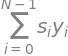

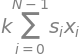

In [ ]:
#N = 2
N = sp.symbols('N', integer=True, positive=True)
a = sp.IndexedBase('a')
b = sp.IndexedBase('b')

x = sp.IndexedBase('x')
y = sp.IndexedBase('y')
z = sp.IndexedBase('z')
s = sp.IndexedBase('s')

#w = sp.MatrixSymbol('w', N, N)
#w = sp.Matrix(sp.symbols('w0:3_0:3'))
w = sp.IndexedBase('w')

i, j = sp.symbols('i j', integer=True)

i = sp.symbols('i', integer=True)
expr = x[i]      # single-index access

#x = sp.MatrixSymbol('x', N, 1)
#w = sp.MatrixSymbol('w', N, 1)
dot =  sp.Lambda((a, b), sp.summation(a[i] * b[i], (i, 0, N-1)))
f = sp.Lambda(x, k * x)
#x[0]
display(s)
display(w[0,:])
display(z)
display(y)
display(expr)
display(dot(s, y))
y = f(dot(s, x))
display(y)
y_ = y.subs(N, 2)


display(sp.simplify(y_))



In [ ]:

x = sp.IndexedBase('x')
w = sp.IndexedBase('w')
zs = sp.IndexedBase('z^s')
s = sp.IndexedBase('s')
z = sp.IndexedBase('z')
N = sp.symbols('N', integer=True, positive=True)
i, j, k = sp.symbols('i j k', integer=True)


dot =  sp.Lambda((a, b), sp.summation(a[i] * b[i], (i, 0, N-1)))
dot_row = sp.Lambda((w, x, i), sp.summation(w[i, j] * x[j], (j, 0, N-1)) )
f = sp.Lambda(x, k * x)

y = dot_row(w, zs, i)

N_ = 2
y_  = y.subs(N, N_)
y_ = y_.subs(N, N_).doit()
eqdisplay('y', y_)
pz = f(y)
pz_ = pz.subs(N, N_).doit()
eqdisplay('p_z', pz_)
for _i, zs_v in enumerate(Zs.states):
    d = {zs[i]: zs_v[i] for i in range(Zs.N)}
    #mdisplay('d_'+Zs.names[_i], d)
    print(d)
    zs_p = pz_.subs(d)    
    eqdisplay('p^z_s'+Zs.names[_i], zs_p)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

{z^s[0]: 0, z^s[1]: 0}


<IPython.core.display.Math object>

{z^s[0]: 0, z^s[1]: 1}


<IPython.core.display.Math object>

{z^s[0]: 1, z^s[1]: 0}


<IPython.core.display.Math object>

{z^s[0]: 1, z^s[1]: 1}


<IPython.core.display.Math object>

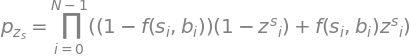

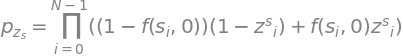

In [ ]:
f = sp.Function('f')
idx = sp.Wild('idx')

zs = sp.IndexedBase('z^s')

term = zs[i] * f(s[i], b[i]) + (1 - zs[i]) * (1 - f(s[i], b[i]))

p_zs = sp.Product(term, (i, 0, N-1))

zs_v = np.array([1, 0])
d = {zs[i]: zs_v[i] for i in range(zs_v.shape[0])}
p_zs = p_zs.subs(d)
eqdisplay('p_{z_s}', p_zs)
p_zs_ = p_zs.replace(lambda a: a.func == f, lambda a: k*(a.args[0] - a.args[1]))
p_zs_ = p_zs.replace(lambda a: getattr(a, "is_Indexed", False) and a.base == b, lambda a: sp.Integer(0))
eqdisplay('p_{z_s}', p_zs_)
idx = sp.Wild('idx')
p_zs_ = p_zs_.subs(N, N_).doit()
p_zs_ = p_zs_.subs(b[idx], 0)
#p_zs_ = p_zs_.subs(b[idx], 0).doit()
eqdisplay('p_{z_s}', p_zs_)



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [74]:
Zy.marginalize()
Zy.display_pmargin()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [227]:
q_zy = marginalize(S_zy, pp_zy, N_, 'z^y')
mdisplay(q_zy)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [156]:
N, M = sp.symbols('N M', integer=True, positive=True)
N_ = 2
M_ = 2
w = sp.IndexedBase('w')
W = sp.Matrix(N_, M_, lambda i, j: w[i, j])
display(W)


⎡w[0, 0]  w[0, 1]⎤
⎢                ⎥
⎣w[1, 0]  w[1, 1]⎦

In [155]:
W = sp.MatrixSymbol('W', N, M)
display(W)
display(W[i,j])


In [150]:
w = sp.Matrix(sp.symbols('w0:3_0:3'))
display(w)

⎡w₀ ₀⎤
⎢    ⎥
⎢w₀ ₁⎥
⎢    ⎥
⎢w₀ ₂⎥
⎢    ⎥
⎢w₁ ₀⎥
⎢    ⎥
⎢w₁ ₁⎥
⎢    ⎥
⎢w₁ ₂⎥
⎢    ⎥
⎢w₂ ₀⎥
⎢    ⎥
⎢w₂ ₁⎥
⎢    ⎥
⎣w₂ ₂⎦